In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

# **Question 1: Verify that the data contain 10 brands and the years 2019-2023.**

In [3]:
#1 Verifying Data

df = pd.read_csv("air_fryers_clean_brand_year.csv")
print(df.shape)
print(df.head())
print(df["brand"].unique())
print(df['year'].unique())

print(f"Number of unique brands: {df['brand'].nunique()}")
print(f"Number of years: {sorted(df['year'].unique())}")

# length 10 present
# years 2019-2023 present

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

**Question 1 Answer:** There are confirmed 10 brands and 5 years, 2019-2023, present in the data.

Length is 10 brands: 'chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster','ultrean'.
Years: 2019, 2020, 2021, 2022, 2023

# **Question 2: Plot the following over time by brand:**
   - average price
   - average rating
   - brand market share

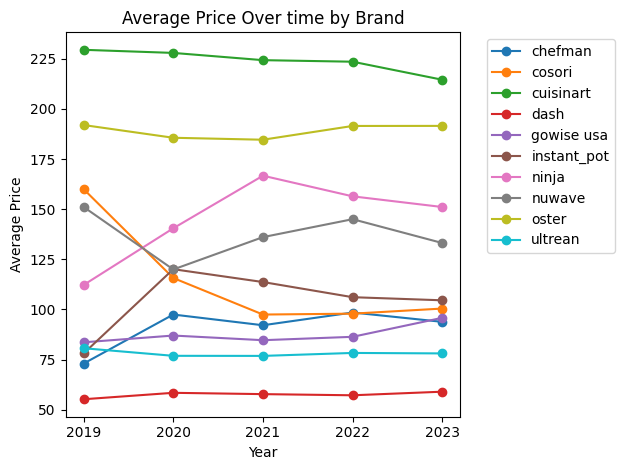

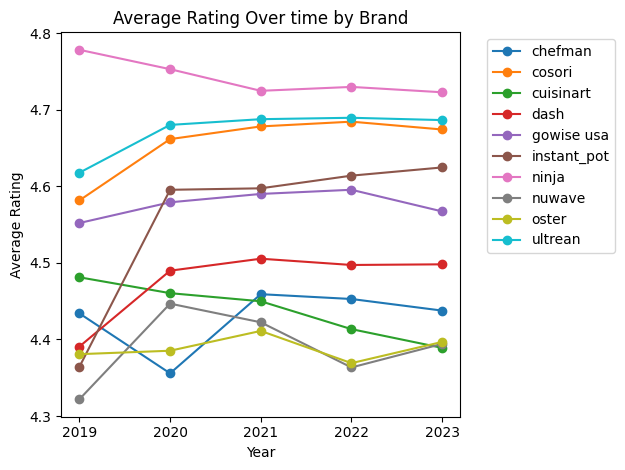

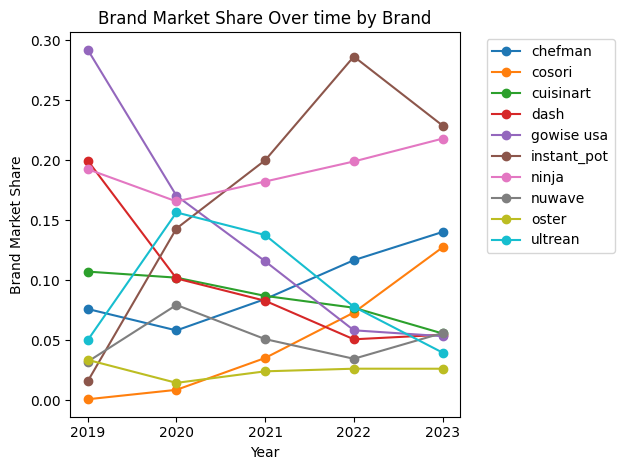

In [6]:
#2. Plots
# Plot #1: average price over time by brand
plt.figure()

for brand in df['brand'].unique():
    i = df[df['brand'] == brand]
    plt.plot(i['year'], i['avg_price'], label=brand, marker='o')

plt.title('Average Price Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Average Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot #2: average rating over time by brand
plt.figure()

for brand in df['brand'].unique():
    i = df[df['brand'] == brand]
    plt.plot(i['year'], i['avg_rating'], label=brand,  marker='o')

plt.title('Average Rating Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot #3: brand market share over time by brand
plt.figure()

for brand in df['brand'].unique():
    i = df[df['brand'] == brand]
    plt.plot(i['year'], i['brand_share'], label=brand, marker='o')


plt.title('Brand Market Share Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Brand Market Share')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Question 2 Answer:** Average prices are relatively stable over time for most brands with Cusinart and Oster being the most expensive and Dash being the cheapest. Ratings are clustered between 4.3 to 4.8 across all brands for each of the years with minimal variation over time. Market share has the most variability with Ninja growing steadily from 2019 to 2023 and GoWise USA declining sharply, which suggests a shift in consumer preferences toward Ninja over this observation window.

# **Question 3: Summarize the product characteristics:**
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?

In [8]:
features = ['compact_share', 'dual_basket_share', 'oven_style_share', 
                'rotisserie_share', 'window_share']

df.groupby('brand')[features].mean().round(3)

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.962,0.013,0.597,0.370,0.363
cosori,0.997,0.000,0.030,0.024,0.000
cuisinart,0.996,0.000,0.913,0.000,0.000
dash,0.999,0.000,0.890,0.000,0.000
gowise usa,1.000,0.000,0.184,0.184,0.001
instant_pot,0.860,0.000,0.675,0.102,0.003
ninja,0.992,0.002,0.100,0.000,0.000
nuwave,0.995,0.007,0.543,0.027,0.000
oster,1.000,0.000,0.865,0.000,0.000


#3 Product Characteristics


**Question 3 Answer:**


**Common Features**: Compact design is the most common feature accross brands, with a compact_share near 1.0 for almost all brands, indicating that most of each of these brands' products are compact style. Oven-style models are the secondary dominant format, particularly for Cuisinart, Oster, Dash, Chefman, Instant Pot, and Ultrean.

**Rare Features**: Dual-basket models are much less prevalent across brands; with near zero dual_basket_share for most brands. Additionally, Rotisserie and Window features are more niche, and appear primarily in a small subset of models from brands like Chefman, GoWise USA.

**Brand Specialization**:
- Premium/Oven Specialists: Cuisinart and Oster focus on high-priced, oven-style units.
- Value Specialists: Dash and Ultrean focus almost exclusively on low-cost, compact models with minimal feature variety.
- Feature Leaders: Chefman and GoWise USA are more likely to incorporate "rare" features like rotisserie functions and window functions compared to the rest of the market.

# **Question 4: Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?**

In [9]:
df.groupby('brand')[['avg_price', 'avg_rating', 'brand_share']].mean().round(3).sort_values('brand_share', ascending=False)

,avg_price,avg_rating,brand_share
brand,,,
ninja,145.343,4.742,0.192
instant_pot,104.461,4.559,0.175
gowise usa,87.455,4.577,0.138
dash,57.479,4.476,0.098
chefman,90.938,4.428,0.095
ultrean,78.115,4.673,0.092
cuisinart,223.947,4.439,0.086
nuwave,137.024,4.390,0.051
cosori,114.268,4.656,0.049



#4. Market Description

**Question 4 Answer:**


Price Positioning: The air fryer market is tiered by price. Cuisinart and Oster target the premium segment, with an average price greater than '$180', while Dash and Ultrean anchor the budget segment, with an average price less than '$80'.
Market Share Leaders: Instant Pot and Ninja are the current market leaders. Ninja holds the highest average market share of 19.2% and leads in consumer ratings with an average rating of 4.742. Instant Pot’s trajectory is impressive, rising from a negligible share in 2019 to becoming the market leader by 2022, as seen in the chart from question 2. Instant Pot has the second highest average market share of 17.5%. 
Market Stability: Contrary to being "stable," the market has been relatively volatile. GoWise USA experienced a massive collapse, dropping from the #1 spot in market share in 2019 to a minor player by 2023, which Instant Pot and Ninja gained share with their "disruptive growth" by rapidly seizing share from brands losing share.
Quality vs. Competition: Because Average Ratings are consistently high ( between 4.3 and 4.8) across all brands, the market is not competing on basic quality. Instead, brands are fighting for dominance through pricing strategy and brand identity.